<a href="https://colab.research.google.com/github/giolanta-nta/Homework/blob/main/Week_6_HW_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import RepeatedKFold

In [2]:
df_wine = pd.read_csv("/content/winequality-white.csv", sep=";", header=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [5]:
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [7]:
df_wine.shape

(4898, 12)

In [9]:
df_wine.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [10]:
df_wine.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [13]:
df_wine.dropna(inplace=True)

In [17]:
x = df_wine.drop('quality', axis=1)
y = df_wine['quality']

In [20]:
from sklearn.model_selection import train_test_split
wine_train, wine_test = train_test_split(df_wine, random_state=42)

In [21]:
x_train = wine_train.drop('quality', axis=1)
y_train = wine_train['quality']

In [22]:
x_test = wine_test.drop('quality', axis=1)
y_test = wine_test['quality']


In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
lm=LinearRegression()
lm.fit(x_train,y_train)
y_pred = lm.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = round(r2_score(y_test, y_pred), 2)
b = lm.coef_
d = lm.intercept_
txt = "R2 = {} \nRMSE = {} \ncoef = {} \nintercept = {}"
print(txt.format(r2, rmse, b, d))

R2 = 0.29 
RMSE = 0.73657906999481 
coef = [ 5.06457657e-02 -1.96341559e+00 -9.16375388e-03  7.69603869e-02
 -6.04146574e-01  3.16302854e-03 -4.93886000e-05 -1.36198618e+02
  6.71592832e-01  5.59628711e-01  2.07470147e-01] 
intercept = 136.2984378372569


                      Importance
alcohol                 0.237292
volatile acidity        0.121219
free sulfur dioxide     0.119278
density                 0.082955
residual sugar          0.075412
chlorides               0.071945
pH                      0.064564
sulphates               0.064053
total sulfur dioxide    0.064017
fixed acidity           0.054347
citric acid             0.044918


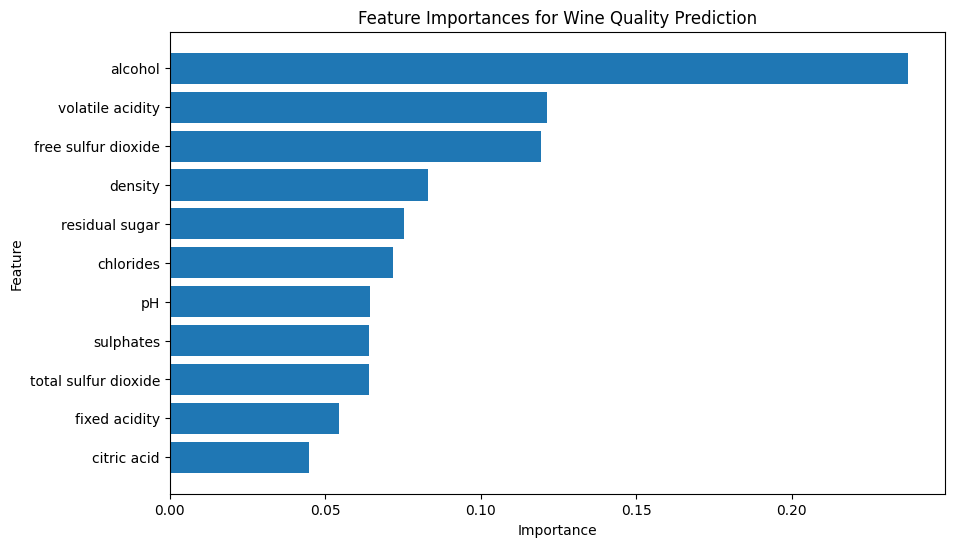

In [28]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

feature_importances = pd.DataFrame(dt_model.feature_importances_, index=x_train.columns, columns=['Importance'])
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances.index, feature_importances['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances for Wine Quality Prediction')
plt.gca().invert_yaxis() # To show the most important feature at the top
plt.show()

Text(0.5, 1.0, 'Correlation of alcohol and wine quality')

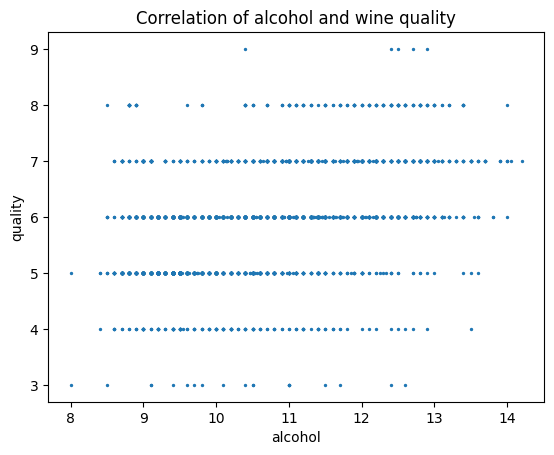

In [45]:
plt.scatter(df_wine['alcohol'], df_wine['quality'], s = 2)
plt.xlabel("alcohol")
plt.ylabel("quality")
plt.title("Correlation of alcohol and wine quality")

In [34]:
x = wine_train.drop('quality', axis=1)
y = wine_train['quality']

In [38]:
r2 = round(r2_score(y_test, y_pred), 2)
print(r2)

0.29


In [39]:
X_full = df_wine.drop('quality', axis=1)
Y_full = df_wine['quality']

r2_scores = []

our_cv = RepeatedKFold(n_splits=10, n_repeats=3)
for i_train, i_test in our_cv.split(X_full, Y_full):
    X_train, X_test, y_train, y_test = X_full.iloc[i_train], X_full.iloc[i_test], Y_full.iloc[i_train], Y_full.iloc[i_test]
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    y_pred_test = lin_reg.predict(X_test)
    r2 = round(lin_reg.score(X_test, y_test), 2)
    r2_scores.append(r2)

print(f"R2 scores from cross-validation: {r2_scores}")
print(f"Mean R2 score: {np.mean(r2_scores):.2f}")
print(f"Standard deviation of R2 scores: {np.std(r2_scores):.2f}")

R2 scores from cross-validation: [0.27, 0.3, 0.27, 0.27, 0.35, 0.21, 0.28, 0.28, 0.25, 0.26, 0.26, 0.19, 0.28, 0.26, 0.32, 0.32, 0.28, 0.32, 0.27, 0.24, 0.23, 0.3, 0.19, 0.29, 0.3, 0.29, 0.29, 0.25, 0.29, 0.28]
Mean R2 score: 0.27
Standard deviation of R2 scores: 0.04


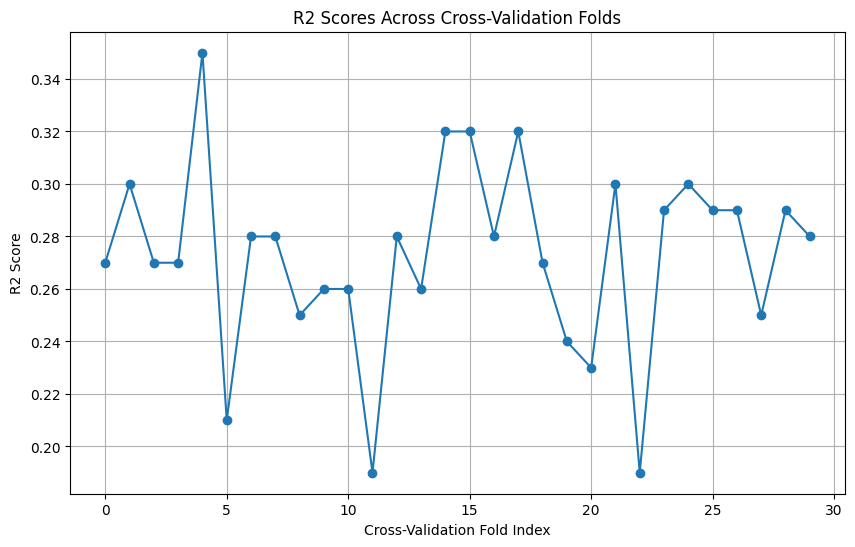

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(r2_scores)), r2_scores, marker='o', linestyle='-')
plt.title('R2 Scores Across Cross-Validation Folds')
plt.xlabel('Cross-Validation Fold Index')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()

In [42]:
from sklearn.tree import DecisionTreeRegressor

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

x = df_wine.drop('quality', axis=1)
y = df_wine['quality']

# Re-perform the train-test split to ensure consistency
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

regr_tree = DecisionTreeRegressor(max_depth=6, random_state=42)
regr_tree.fit(x_train, y_train)

y_pred_dt = regr_tree.predict(x_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = round(r2_score(y_test, y_pred_dt), 2)

print(f"Decision Tree Regressor (max_depth=6) R2: {r2_dt}")
print(f"Decision Tree Regressor (max_depth=6) RMSE: {rmse_dt}")

Decision Tree Regressor (max_depth=6) R2: 0.27
Decision Tree Regressor (max_depth=6) RMSE: 0.748282939895966


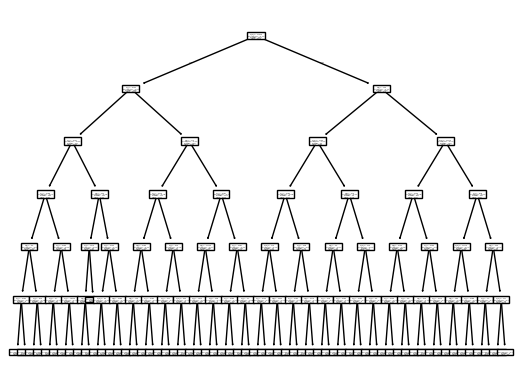

In [46]:
plot_tree(regr_tree)
plt.show()

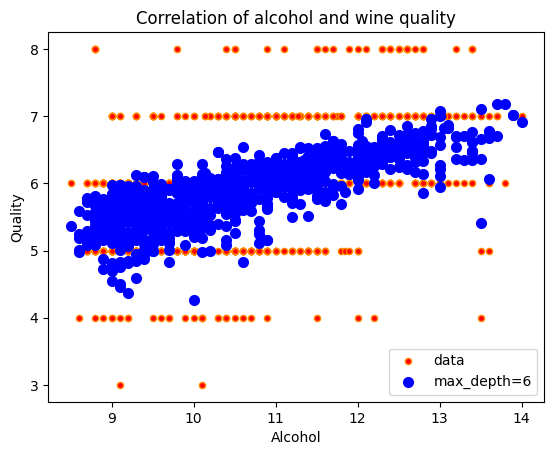

In [48]:
plt.figure()
plt.scatter(x_test['alcohol'], y_test, s=20, edgecolor="darkorange",
            c="r", label="data")
plt.scatter(x_test['alcohol'], y_pred, color="b", label="max_depth=6", linewidth=2)
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Correlation of alcohol and wine quality")
plt.legend()
plt.show()

**Linear regression -> R2: 0.29 / Decision tree + Cross validation -> R2: 0.27**